# Hidden-Entrepreneur Detection

Train a per-card classifier on the two labeled pools (consumer / business), then
score the consumer pool out-of-fold to find cards that behave like a business but
are filed as a consumer. The bank can move those clients to SME products
(POS acquiring, working-capital loans, payroll, cash management, bookkeeping).

Data: 105k cards (80k consumer + 25k business), 12.8M transactions over 6 months,
Kazakhstan-time timestamps. Synthetic, but the same pipeline transfers to real data.

Output: `submission.csv` with one row per `card_number` and a `score` in [0, 1].

Run top to bottom. Everything is seeded.

## 1. Setup

In [1]:
from __future__ import annotations
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             classification_report, precision_recall_curve, roc_curve)
from lightgbm import LGBMClassifier
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning, module="shap")

SEED = 42
CONSUMER_FILE = "consumer_cards_MDQ.parquet"
BUSINESS_FILE = "business_cards_MDQ.parquet"
MERCHANT_FILE = "merchants_reference.parquet"
CACHE_FILE    = "features_card_level.parquet"
SUBMISSION    = "submission.csv"
LEADS_FILE    = "hidden_entrepreneurs.csv"

ID_COL, LABEL_COL = "card_number", "label"
TEST_SIZE, N_SPLITS = 0.20, 5
LEAD_THR = 0.30          # consumer score cutoff for the leads file
OUTREACH_PRECISION = 0.50

# B2B / wholesale / professional-services MCCs, curated from MCC semantics.
# 5122 sits in this category by definition but only business cards use it in this
# sample, so it would leak into b2b_*_share if kept. Hence excluded.
B2B_MCC = {
    "5044","5045","5046","5047","5051","5065","5072","5074","5085",
    "5111","5131","5137","5139","5169","5172","5192","5198","5199",
    "7311","7321","7333","7338","7339","7342","7349","7361","7372",
    "7375","7379","7392","7393","7394","7399","8742","8911","8931",
    "2741","2791","2842",
    "4214","4215","4225","4816",
}
DROP_COLS = ["card_tier", "bank_name"]


def ranking_metrics(y, p):
    return {"ROC_AUC": roc_auc_score(y, p), "PR_AUC": average_precision_score(y, p)}


def metrics_at_threshold(y, p, thr):
    yhat = (p >= thr).astype(int)
    return {"threshold": float(thr),
            "precision": precision_score(y, yhat, zero_division=0),
            "recall":    recall_score(y, yhat, zero_division=0),
            "f1":        f1_score(y, yhat, zero_division=0),
            "confusion": confusion_matrix(y, yhat)}


def tune_thresholds(y, proba, min_precision=OUTREACH_PRECISION):
    # f1: strict cutoff for automated migration.
    # outreach: smallest cutoff where precision is still acceptable, so the lead
    # pool stays as large as possible (a missed SME costs more than one cheap call).
    prec, rec, thr = precision_recall_curve(y, proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    thr_f1 = float(thr[np.nanargmax(f1[:-1])])
    mask = prec[:-1] >= min_precision
    thr_outreach = float(thr[mask].min()) if mask.any() else thr_f1
    return {"f1": thr_f1, "outreach": thr_outreach}


def oof_proba(make_estimator, X, y, seed=SEED, n_splits=N_SPLITS):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return cross_val_predict(make_estimator(), X, y, cv=skf,
                             method="predict_proba", n_jobs=-1)[:, 1]


def shap_positive(explainer, X):
    sv = explainer.shap_values(X)
    if isinstance(sv, list):
        return np.asarray(sv[1])
    sv = np.asarray(sv)
    return sv[:, :, 1] if sv.ndim == 3 else sv


def plot_confusion(cm, ax, title=""):
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v}", ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["consumer", "business"])
    ax.set_yticklabels(["consumer", "business"])
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)


np.random.seed(SEED)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 110
print("setup ok, seed =", SEED)

setup ok, seed = 42


C:\Users\olzha\OneDrive\Рабочий_стол\MDQ\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load data

In [2]:
consumer  = pd.read_parquet(CONSUMER_FILE)
business  = pd.read_parquet(BUSINESS_FILE)
merchants = pd.read_parquet(MERCHANT_FILE)
print("consumer", consumer.shape, "| business", business.shape, "| merchants", merchants.shape)
display(consumer.dtypes.to_frame("dtype"))
display(consumer.head(3))

consumer (9832487, 12) | business (2997593, 12) | merchants (2165, 5)


,dtype
transaction_date,object
transaction_timestamp,datetime64[ms]
transaction_amount_kzt,int64
mcc,str
merchant_id,str
channel,str
bank_name,str
country,str
card_number,str
card_tier,str


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01 00:04:00,4788,4814,MER_000064,online,Alatau City Bank,Kazakhstan,5263907968824596,Standard,False,True
1,2025-10-01,2025-10-01 00:10:00,5240,4814,MER_000063,online,Bank RBK,Kazakhstan,5119023663984986,Standard,False,True
2,2025-10-01,2025-10-01 00:12:00,4576,4814,MER_000066,online,Kaspi,Kazakhstan,5228590878155154,Standard,False,True


## 3. EDA

A few sanity checks before features: nulls, duplicates, amount range, and the
hour / channel / recurring profile differences that the model should pick up.

In [3]:
def load_labeled():
    c = pd.read_parquet(CONSUMER_FILE); c[LABEL_COL] = 0
    b = pd.read_parquet(BUSINESS_FILE); b[LABEL_COL] = 1
    return pd.concat([c, b], ignore_index=True)


df = load_labeled()
print(f"rows={len(df):,}  cards={df[ID_COL].nunique():,}  "
      f"consumer={df.loc[df.label==0, ID_COL].nunique():,}  "
      f"business={df.loc[df.label==1, ID_COL].nunique():,}")
print(f"nulls={int(df.isna().sum().sum())}  duplicates={int(df.duplicated().sum())}")
print(f"timestamp: {df.transaction_timestamp.min()}  ->  {df.transaction_timestamp.max()}")
print(f"amount KZT: min={df.transaction_amount_kzt.min():,}  "
      f"max={df.transaction_amount_kzt.max():,}  "
      f"non-positive={(df.transaction_amount_kzt <= 0).sum()}")

print("\namount per class:")
display(df.groupby(LABEL_COL).transaction_amount_kzt
          .describe(percentiles=[.5, .9, .99]).round(0))

rows=12,830,080  cards=105,000  consumer=80,000  business=25,000


nulls=0  duplicates=0
timestamp: 2025-10-01 00:00:00  ->  2026-03-31 23:59:53
amount KZT: min=15  max=40,799,297  non-positive=0

amount per class:


,count,mean,std,min,50%,90%,99%,max
label,,,,,,,,
0,9832487.0,54045.0,169655.0,15.0,11892.0,117999.0,699869.0,31971032.0
1,2997593.0,156535.0,252868.0,67.0,77224.0,381919.0,1090845.0,40799297.0


,consumer,business
online,0.465,0.847
is_recurring,0.027,0.133
tokenized,0.386,0.600
wknd,0.348,0.125
eve,0.375,0.121
bizhours,0.342,0.607


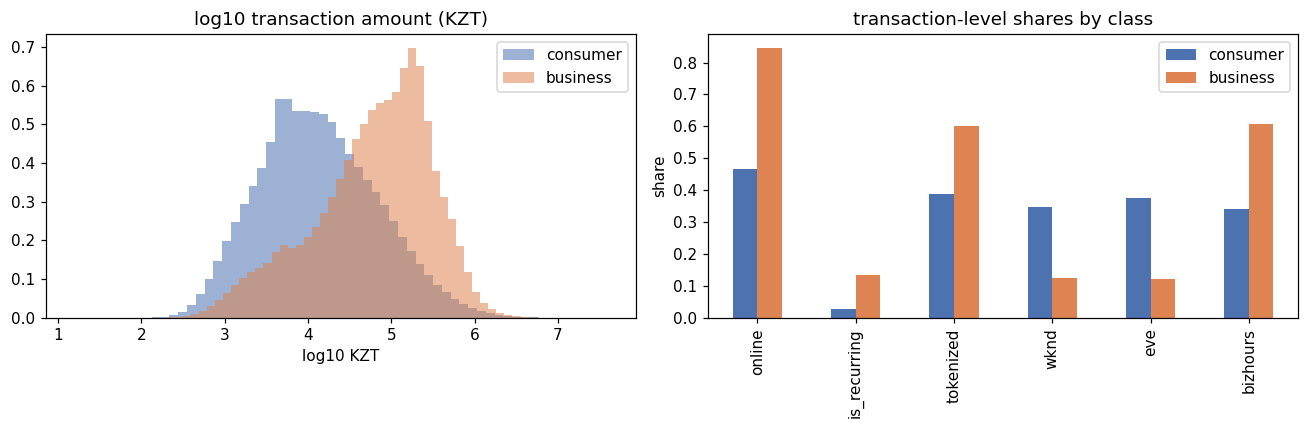

In [4]:
# Transaction-level share contrast. The class gap on these signals shows up
# again as feature gaps once we aggregate per card.
ts = pd.to_datetime(df["transaction_timestamp"])
sig = df.assign(
    online   = (df.channel == "online"),
    wknd     = (ts.dt.dayofweek >= 5),
    eve      = ts.dt.hour.between(18, 23),
    bizhours = (ts.dt.dayofweek < 5) & ts.dt.hour.between(9, 17),
)
contrast = (sig.groupby(LABEL_COL)[["online","is_recurring","tokenized","wknd","eve","bizhours"]]
              .mean().T)
contrast.columns = ["consumer", "business"]
display(contrast.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for lab, name, col in [(0, "consumer", "#4C72B0"), (1, "business", "#DD8452")]:
    ax[0].hist(np.log10(df.loc[df.label == lab, "transaction_amount_kzt"].clip(lower=1)),
               bins=60, alpha=.55, label=name, color=col, density=True)
ax[0].set_title("log10 transaction amount (KZT)")
ax[0].set_xlabel("log10 KZT"); ax[0].legend()
contrast.plot.bar(ax=ax[1], color=["#4C72B0", "#DD8452"])
ax[1].set_title("transaction-level shares by class")
ax[1].set_ylabel("share")
plt.tight_layout(); plt.show()

## 4. Leakage screen

Two known hazards in synthetic data: a perfect-separator column, and high-cardinality
ID-like columns that look harmless but split the classes by coverage. We flag and
drop them here so the rest of the pipeline is forced to find behavior, not artifacts.

In [5]:
print("card_tier x label (consumer cards never carry a Business-tier):")
display(pd.crosstab(df.label, df.card_tier))

con_m, biz_m = df[df.label == 0], df[df.label == 1]
for col in ["mcc", "merchant_id"]:
    cset, bset = set(con_m[col].unique()), set(biz_m[col].unique())
    only_b = bset - cset
    vol = biz_m[col].isin(only_b).mean()
    print(f"{col:11s}  biz_only={len(only_b):4d}  con_only={len(cset-bset):4d}  "
          f"shared={len(cset & bset):4d}   biz vol in biz-only {col}: {vol:.3%}")

# Sanity check on the curated basket: no business-exclusive code may sneak in.
biz_only_mcc = set(biz_m.mcc.unique()) - set(con_m.mcc.unique())
basket_leak  = sorted(B2B_MCC & biz_only_mcc)
print(f"\nB2B basket size: {len(B2B_MCC)}  "
      f"basket ∩ biz-exclusive: {basket_leak or 'none'}")
print(f"dropped before modeling: {DROP_COLS}")

card_tier x label (consumer cards never carry a Business-tier):


card_tier,Affluent,Business,Premium,Standard
label,,,,
0,2061920,0,441717,7328850
1,0,2997593,0,0


mcc          biz_only=  32  con_only= 428  shared=  72   biz vol in biz-only mcc: 3.150%


merchant_id  biz_only= 105  con_only=1684  shared= 376   biz vol in biz-only merchant_id: 3.150%

B2B basket size: 43  basket ∩ biz-exclusive: none
dropped before modeling: ['card_tier', 'bank_name']


## 5. Card-level features

35 features in five rough groups: spend volume and dispersion, merchant diversity
and concentration, B2B exposure (count, amount share, supplier breadth), temporal
and recurring patterns, and inter-arrival burstiness.

Aggregations are always per `card_number`, so transaction-level leakage cannot
survive the rollup.

In [6]:
def _helpers(df):
    ts = pd.to_datetime(df["transaction_timestamp"])
    df["_hour"]       = ts.dt.hour.astype("int16")
    dow               = ts.dt.dayofweek.astype("int16")
    df["_is_weekend"] = (dow >= 5)
    df["_is_evening"] = df["_hour"].between(18, 23)
    df["_is_bizhours"]= (~df["_is_weekend"]) & df["_hour"].between(9, 17)
    df["_is_online"]  = (df["channel"] == "online")
    df["_is_foreign"] = (df["country"] != "Kazakhstan")
    df["_is_b2b_mcc"] = df["mcc"].isin(B2B_MCC)
    df["_amt"]        = df["transaction_amount_kzt"].astype("float64")
    df["_date"]       = ts.dt.normalize()
    # Period-strings so distinct weeks never collide across year boundaries.
    df["_week"]       = ts.dt.to_period("W").astype("string")
    df["_month"]      = ts.dt.to_period("M").astype("string")
    return df


def _concentration(df, key, prefix):
    g = df.groupby([ID_COL, key], observed=True).size().rename("n")
    p = g / g.groupby(level=0, observed=True).transform("sum")
    return pd.DataFrame({
        f"{prefix}_hhi":       (p * p).groupby(level=0, observed=True).sum(),
        f"{prefix}_top_ratio":  p.groupby(level=0, observed=True).max(),
        f"{prefix}_entropy":   (-(p * np.log(p))).groupby(level=0, observed=True).sum(),
    })


def build_card_features(tx, merchants=None):
    tx = _helpers(tx)
    obs_end = tx["_date"].max()
    if merchants is None:
        merchants = pd.read_parquet(MERCHANT_FILE)
    rec_cap = (merchants.drop_duplicates("merchant_id")
                        .set_index("merchant_id")["recurring_capable"])
    tx["_rec_capable"] = tx["merchant_id"].map(rec_cap).fillna(False)

    g = tx.groupby(ID_COL, observed=True)
    feat = g.agg(
        label=("label", "first"),
        tx_count=("_amt", "size"),
        amt_sum=("_amt", "sum"), amt_mean=("_amt", "mean"), amt_median=("_amt", "median"),
        amt_std=("_amt", "std"), amt_max=("_amt", "max"), amt_min=("_amt", "min"),
        n_unique_merchants=("merchant_id", "nunique"),
        n_unique_mcc=("mcc", "nunique"),
        n_unique_countries=("country", "nunique"),
        recurring_share=("is_recurring", "mean"),
        tokenized_share=("tokenized", "mean"),
        online_share=("_is_online", "mean"),
        weekend_share=("_is_weekend", "mean"),
        evening_share=("_is_evening", "mean"),
        bizhours_share=("_is_bizhours", "mean"),
        foreign_share=("_is_foreign", "mean"),
        b2b_mcc_share=("_is_b2b_mcc", "mean"),
        recurring_capable_share=("_rec_capable", "mean"),
        active_days=("_date", "nunique"),
        active_weeks=("_week", "nunique"),
        first_date=("_date", "min"),
        last_date=("_date", "max"),
    )

    # B2B share of spend (not just count): a higher-fidelity exposure signal.
    feat["b2b_amt_share"] = (
        tx.assign(_b2b_amt=tx["_amt"].where(tx["_is_b2b_mcc"], 0.0))
          .groupby(ID_COL, observed=True)["_b2b_amt"].sum() / feat["amt_sum"]
    )
    feat["amt_cv"]            = feat["amt_std"] / feat["amt_mean"].replace(0, np.nan)
    feat["span_days"]         = (feat["last_date"] - feat["first_date"]).dt.days + 1
    feat["tx_per_active_day"] = feat["tx_count"] / feat["active_days"]
    feat["recency_days"]      = (obs_end - feat["last_date"]).dt.days
    feat["merchants_per_tx"]  = feat["n_unique_merchants"] / feat["tx_count"]
    feat = feat.join(_concentration(tx, "merchant_id", "merchant"))

    b2b_u = tx[tx["_is_b2b_mcc"]].groupby(ID_COL, observed=True)["merchant_id"].nunique()
    feat["b2b_unique_merchants"] = b2b_u.reindex(feat.index).fillna(0).astype("int64")

    monthly = tx.groupby([ID_COL, "_month"], observed=True)["_amt"].sum()
    mm = monthly.groupby(level=0, observed=True).agg(m="mean", s="std")
    feat["monthly_spend_cv"] = mm["s"] / mm["m"].replace(0, np.nan)

    d = tx[[ID_COL, "transaction_timestamp"]].sort_values([ID_COL, "transaction_timestamp"])
    gap_h = (d.groupby(ID_COL, observed=True)["transaction_timestamp"]
               .diff().dt.total_seconds() / 3600.0)
    gstat = (d.assign(gap=gap_h)
              .groupby(ID_COL, observed=True)["gap"]
              .agg(gap_mean="mean", gap_std="std"))
    # Goh-Barabasi burstiness in [-1, 1]: >0 bursty, <0 regular.
    gstat["burstiness"] = ((gstat["gap_std"] - gstat["gap_mean"]) /
                           (gstat["gap_std"] + gstat["gap_mean"]).replace(0, np.nan))
    feat = feat.join(gstat)

    feat = feat.drop(columns=["first_date", "last_date"])
    # Cards with one transaction have no std / no gaps; fill those with 0.
    feat = feat.fillna({"amt_std": 0.0, "amt_cv": 0.0, "gap_mean": 0.0,
                        "gap_std": 0.0, "burstiness": 0.0, "monthly_spend_cv": 0.0})
    return feat.reset_index()


if os.path.exists(CACHE_FILE):
    feat = pd.read_parquet(CACHE_FILE)
    print(f"loaded cached features {feat.shape}")
else:
    feat = build_card_features(df, merchants)
    feat.to_parquet(CACHE_FILE, index=False)
    print(f"built features {feat.shape}")

FEATURES = [c for c in feat.columns if c not in (ID_COL, LABEL_COL)]
print(f"features={len(FEATURES)}  positive_rate={feat[LABEL_COL].mean():.4f}")
del df; gc.collect()
display(feat[FEATURES].head(3))

loaded cached features (105000, 37)
features=35  positive_rate=0.2381


,tx_count,amt_sum,amt_mean,amt_median,amt_std,amt_max,amt_min,n_unique_merchants,n_unique_mcc,n_unique_countries,recurring_share,tokenized_share,online_share,weekend_share,evening_share,bizhours_share,foreign_share,b2b_mcc_share,recurring_capable_share,active_days,active_weeks,b2b_amt_share,amt_cv,span_days,tx_per_active_day,recency_days,merchants_per_tx,merchant_hhi,merchant_top_ratio,merchant_entropy,b2b_unique_merchants,monthly_spend_cv,gap_mean,gap_std,burstiness
0,178,9651486.0,54221.831461,14499.0,92378.778008,745914.0,659.0,9,9,9,0.067416,0.646067,0.865169,0.101124,0.151685,0.640449,0.196629,0.146067,0.140449,105,27,0.365837,1.703719,182,1.695238,0,0.050562,0.253566,0.432584,1.700050,4,0.229397,24.583851,28.329965,0.070797
1,106,14353608.0,135411.396226,67810.0,198947.026012,1483178.0,604.0,18,18,5,0.169811,0.632075,0.905660,0.122642,0.150943,0.613208,0.273585,0.584906,0.452830,80,27,0.854934,1.469204,182,1.325000,0,0.169811,0.187967,0.349057,2.119791,9,0.339206,41.292958,40.232464,-0.013008
2,148,13102356.0,88529.432432,56445.0,101798.906783,652796.0,262.0,8,8,3,0.040541,0.655405,0.891892,0.114865,0.101351,0.716216,0.195946,0.790541,0.067568,90,27,0.777215,1.149888,182,1.644444,0,0.054054,0.271366,0.466216,1.645914,6,0.171563,29.573228,33.904017,0.068226


In [7]:
# Quick sanity: do the features separate the classes the way we expect?
g = feat.groupby(LABEL_COL)[FEATURES].mean().T
g.columns = ["consumer", "business"]
g["b/c"] = (g.business / g.consumer.replace(0, np.nan)).round(2)
display(g.round(3))

,consumer,business,b/c
tx_count,122.906,1.199040e+02,0.98
amt_sum,6642511.708,1.876916e+07,2.83
amt_mean,54770.136,1.676424e+05,3.06
amt_median,23119.451,9.222524e+04,3.99
amt_std,99972.460,2.301465e+05,2.30
amt_max,736432.469,1.494760e+06,2.03
amt_min,1095.117,1.810038e+03,1.65
n_unique_merchants,36.750,1.708700e+01,0.46
n_unique_mcc,31.683,1.484900e+01,0.47
n_unique_countries,9.048,5.740000e+00,0.63


## 6. Univariate AUC

If a single feature reaches AUC = 1.0 we still have a leak. The top features here
sit at 0.92-0.99 — strong but not perfect, which is what we want.

max univariate AUC: 0.9948


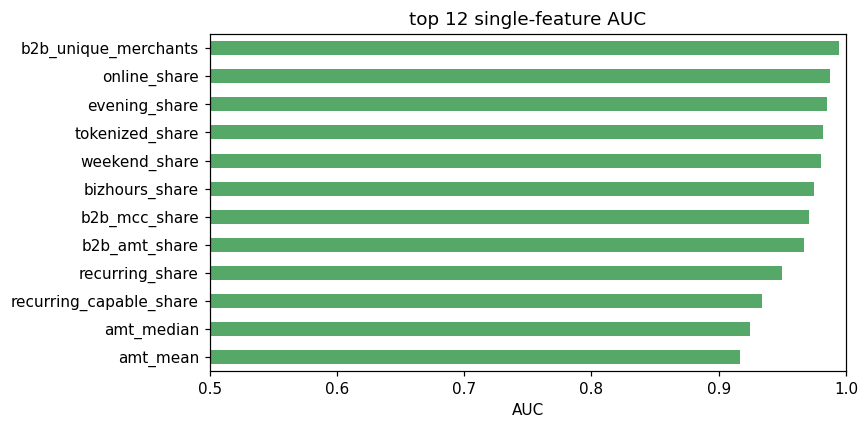

In [8]:
y_all = feat[LABEL_COL].values
uni = pd.Series({c: max(roc_auc_score(y_all, feat[c]),
                        1 - roc_auc_score(y_all, feat[c])) for c in FEATURES})
uni = uni.sort_values(ascending=False)
print(f"max univariate AUC: {uni.max():.4f}")
uni.head(12).iloc[::-1].plot.barh(color="#55A868")
plt.title("top 12 single-feature AUC")
plt.xlabel("AUC"); plt.xlim(0.5, 1.0)
plt.tight_layout(); plt.show()

## 7. Stratified split

One row per `card_number`, so a row-level split is automatically a card-level split.
Stratify on the label to keep the 23.8 % positive rate in both sides.

A chronological split would be the right call if the label was "becomes a business
next quarter", but this label is an intrinsic card type observed over a fixed
window, so random is fine here.

In [9]:
X, y = feat[FEATURES], feat[LABEL_COL].values
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=TEST_SIZE,
                                      stratify=y, random_state=SEED)
print(f"train={Xtr.shape}  val={Xva.shape}  val_pos={yva.mean():.4f}")

train=(84000, 35)  val=(21000, 35)  val_pos=0.2381


## 8. Three models

LogReg is the baseline; LightGBM is the main model; RandomForest is a sanity check.
Logistic regression gets log1p + scaling inside a Pipeline so the transformer is
fit on train only. Tree models take the raw features.

In [10]:
SKEWED = ["tx_count","amt_sum","amt_mean","amt_median","amt_std","amt_max","amt_min",
          "n_unique_merchants","n_unique_mcc","n_unique_countries","active_days",
          "active_weeks","span_days","gap_mean","gap_std","tx_per_active_day",
          "b2b_unique_merchants"]


def make_logreg(features):
    skewed = [c for c in SKEWED if c in features]
    rest   = [c for c in features if c not in skewed]
    log_pipe = Pipeline([
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("sc", StandardScaler()),
    ])
    pre = ColumnTransformer([("log", log_pipe, skewed),
                             ("sc", StandardScaler(), rest)])
    return Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=2000, C=1.0,
                                   class_weight="balanced", random_state=SEED)),
    ])


def make_lgbm():
    return LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        max_depth=-1, min_child_samples=50,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        reg_lambda=1.0, importance_type="gain",
        random_state=SEED, n_jobs=-1, verbose=-1,
    )


def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=20,
        n_jobs=-1, class_weight="balanced", random_state=SEED,
    )


models = {"LogReg": make_logreg(FEATURES), "LightGBM": make_lgbm(), "RandomForest": make_rf()}
fitted, rows = {}, []
for name, m in models.items():
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xva)[:, 1]
    fitted[name] = m
    rows.append({"model": name, **ranking_metrics(yva, p)})
display(pd.DataFrame(rows).set_index("model").round(4))
print("All three saturate near 1.0. The fact that the linear baseline matches")
print("the boosted model is a signal that the classes are near-linearly separable")
print("on these features, not that the trees are overfitting.")

,ROC_AUC,PR_AUC
model,,
LogReg,1.0,1.0
LightGBM,1.0,1.0
RandomForest,1.0,1.0


All three saturate near 1.0. The fact that the linear baseline matches
the boosted model is a signal that the classes are near-linearly separable
on these features, not that the trees are overfitting.


## 9. ROC + PR curves

The dataset is 23.8 % positive, which is not catastrophically imbalanced, but
accuracy is still a bad headline metric: a "predict consumer" classifier scores
76 % accuracy and zero recall on businesses. ROC-AUC is the competition metric;
PR-AUC gives a sharper view of the positive class.

val ranking: {'ROC_AUC': 1.0, 'PR_AUC': 1.0}


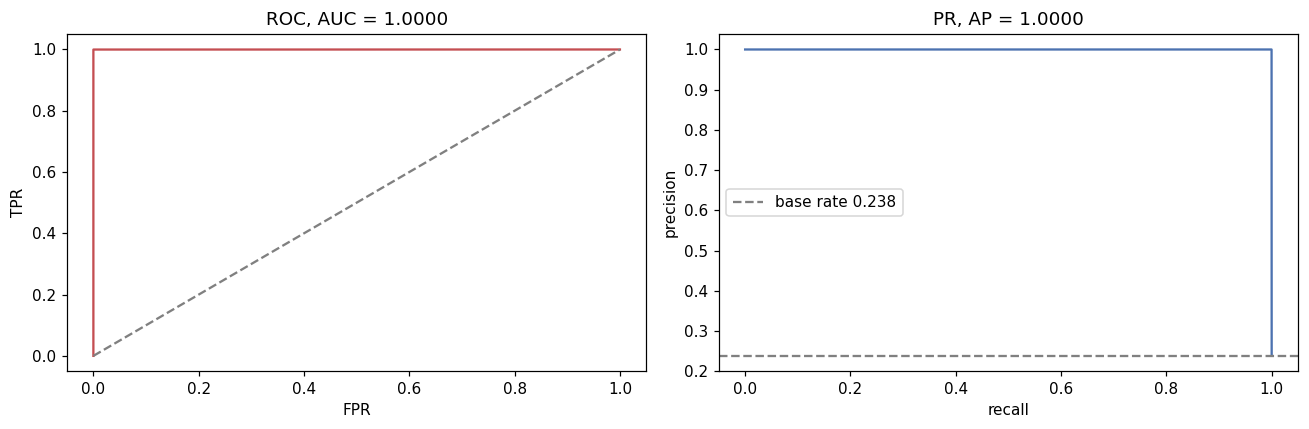

In [11]:
lgbm = fitted["LightGBM"]
pva  = lgbm.predict_proba(Xva)[:, 1]
print("val ranking:", {k: round(v, 4) for k, v in ranking_metrics(yva, pva).items()})

fpr, tpr, _ = roc_curve(yva, pva)
prec_v, rec_v, _ = precision_recall_curve(yva, pva)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fpr, tpr, color="#C44E52")
ax[0].plot([0, 1], [0, 1], "--", color="grey")
ax[0].set_title(f"ROC, AUC = {roc_auc_score(yva, pva):.4f}")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[1].plot(rec_v, prec_v, color="#4C72B0")
ax[1].axhline(yva.mean(), ls="--", color="grey", label=f"base rate {yva.mean():.3f}")
ax[1].set_title(f"PR, AP = {average_precision_score(yva, pva):.4f}")
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Two operating points

Both thresholds are tuned on the **training** OOF scores (not on validation):

- `f1`: F1-max, for an automated tariff-migration trigger that should rarely
  misfire.
- `outreach`: smallest cutoff whose precision is still >= 0.5, used to build an
  RM call list. A missed SME costs more than a cheap call, so we want the lead
  pool as large as it can be while staying at least half-right.

train-OOF thresholds: f1=0.3176  outreach (prec>=0.5)=0.0000
[f1      ] thr=0.3176  prec=1.0000  rec=0.9998  f1=0.9999
[outreach] thr=0.0000  prec=0.5681  rec=1.0000  f1=0.7246


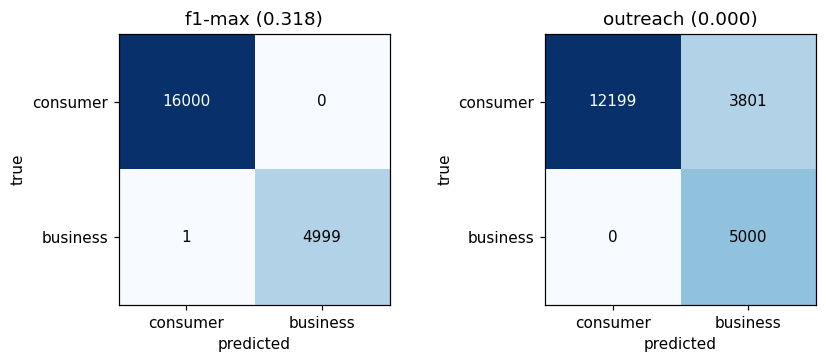


classification report at f1-max:
              precision    recall  f1-score   support

    consumer     0.9999    1.0000    1.0000     16000
    business     1.0000    0.9998    0.9999      5000

    accuracy                         1.0000     21000
   macro avg     1.0000    0.9999    0.9999     21000
weighted avg     1.0000    1.0000    1.0000     21000



In [12]:
thr = tune_thresholds(ytr, oof_proba(make_lgbm, Xtr, ytr))
print(f"train-OOF thresholds: f1={thr['f1']:.4f}  "
      f"outreach (prec>={OUTREACH_PRECISION})={thr['outreach']:.4f}")

for name, t in [("f1", thr["f1"]), ("outreach", thr["outreach"])]:
    m = metrics_at_threshold(yva, pva, t)
    print(f"[{name:8s}] thr={t:.4f}  prec={m['precision']:.4f}  "
          f"rec={m['recall']:.4f}  f1={m['f1']:.4f}")

cm_f1 = metrics_at_threshold(yva, pva, thr["f1"])["confusion"]
cm_or = metrics_at_threshold(yva, pva, thr["outreach"])["confusion"]
fig, ax = plt.subplots(1, 2, figsize=(8, 3.4))
plot_confusion(cm_f1, ax[0], title=f"f1-max ({thr['f1']:.3f})")
plot_confusion(cm_or, ax[1], title=f"outreach ({thr['outreach']:.3f})")
plt.tight_layout(); plt.show()

print("\nclassification report at f1-max:")
print(classification_report(yva, (pva >= thr["f1"]).astype(int),
                            target_names=["consumer", "business"], digits=4))

## 11. SHAP

Global driver order plus a beeswarm. The same explainer feeds the per-card reason
codes in the leads file below.

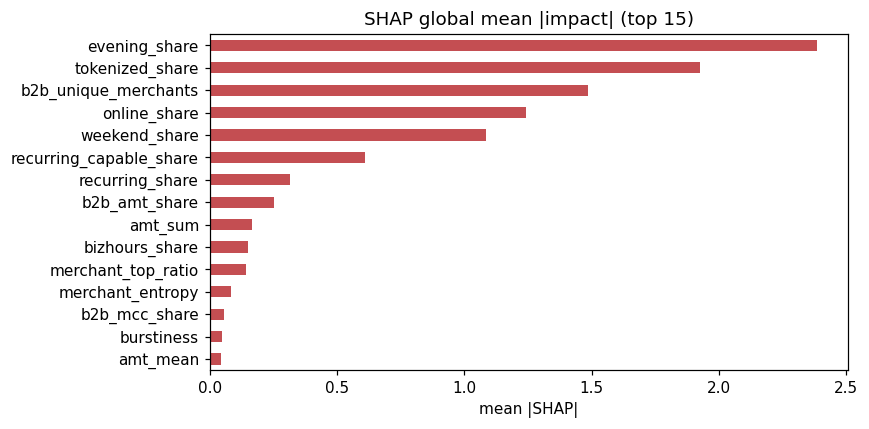

C:\Users\olzha\AppData\Local\Temp\ipykernel_18544\3679524797.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, samp, max_display=15, show=False)


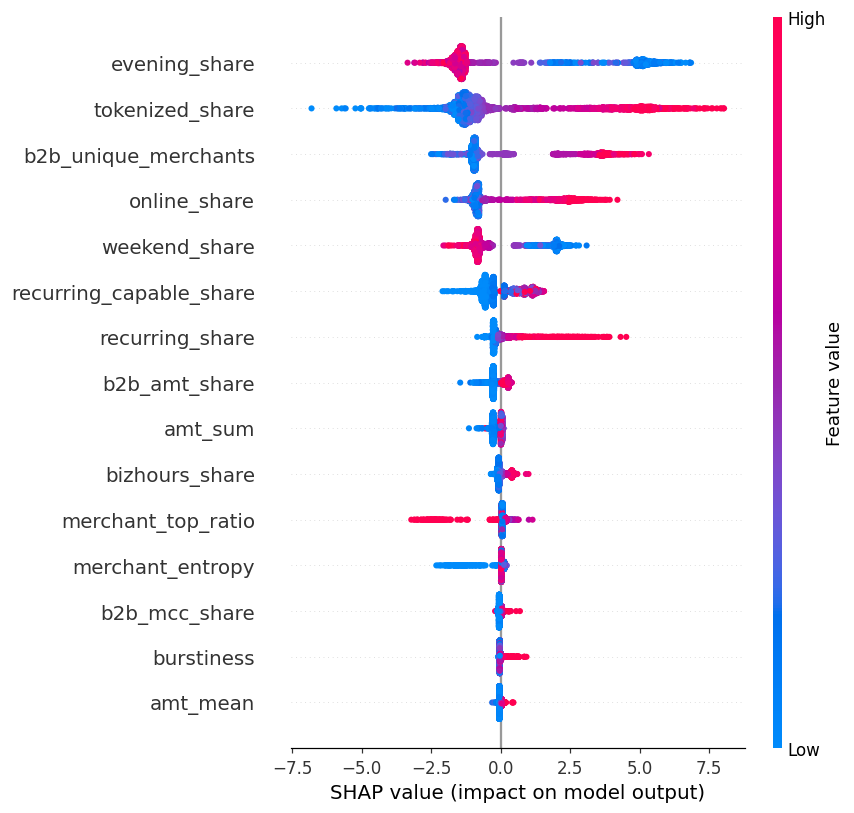

In [13]:
expl = shap.TreeExplainer(lgbm)
samp = X.sample(min(4000, len(X)), random_state=SEED)
shap_vals = shap_positive(expl, samp)

glob = pd.Series(np.abs(shap_vals).mean(0), index=FEATURES).sort_values(ascending=False)
glob.head(15).iloc[::-1].plot.barh(color="#C44E52")
plt.title("SHAP global mean |impact| (top 15)")
plt.xlabel("mean |SHAP|")
plt.tight_layout(); plt.show()

shap.summary_plot(shap_vals, samp, max_display=15, show=False)
plt.tight_layout(); plt.show()

## 12. Out-of-fold scoring of every card

5-fold OOF on the whole labeled set, so each card gets a score from a model that
never trained on it. This is the score we'll use both for the submission file
and for finding hidden entrepreneurs in the consumer pool.

In [14]:
feat["oof_p"] = oof_proba(make_lgbm, X, y)
print("OOF ranking:", {k: round(v, 4) for k, v in ranking_metrics(y, feat.oof_p.values).items()})
display(feat.groupby(LABEL_COL).oof_p.describe(percentiles=[.5, .9, .99, .999]).round(4))

OOF ranking: {'ROC_AUC': 1.0, 'PR_AUC': 1.0}


,count,mean,std,min,50%,90%,99%,99.9%,max
label,,,,,,,,,
0,80000.0,0.0001,0.0081,0.0000,0.0,0.0,0.0,0.0046,0.9923
1,25000.0,0.9997,0.0127,0.0135,1.0,1.0,1.0,1.0000,1.0000


## 13. Submission

`submission.csv` with one row per `card_number` and a `score` column. We write
the OOF scores first and overwrite with the full-refit model at the bottom of
the notebook (the actual scoring artifact).

In [15]:
sub = feat[[ID_COL, "oof_p"]].rename(columns={"oof_p": "score"})
sub.to_csv(SUBMISSION, index=False)
print(f"wrote {SUBMISSION}, rows={len(sub):,}")
display(sub.head())
print("\nscore distribution:")
print(sub.score.describe(percentiles=[.5, .9, .99, .999]).round(4).to_string())

wrote submission.csv, rows=105,000


,card_number,score
0,5100610003025081,9.999896e-01
1,5100610003044611,9.999977e-01
2,5100610003860784,9.999933e-01
3,5100610005930965,1.139480e-02
4,5100610005962109,8.940239e-07



score distribution:
count    105000.0000
mean          0.2381
std           0.4258
min           0.0000
50%           0.0000
90%           1.0000
99%           1.0000
99.9%         1.0000
max           1.0000


## 14. Hidden-entrepreneur leads

Filter consumers (`label == 0`) by OOF score and rank. On this synthetic data
only ~11 consumers cross the 0.30 cutoff; on real bank data the same pipeline
would surface a much larger pool.

Each row of the leads file also gets a short SHAP reason-code string so an RM
can open the file and see the top drivers for that specific card.

consumers=80,000  businesses=25,000
consumers above each cutoff:
  P>=0.10: 22 (0.028%)
  P>=0.20: 14 (0.017%)
  P>=0.30: 11 (0.014%)
  P>=0.50: 5 (0.006%)
  P>=0.80: 4 (0.005%)
  P>=0.90: 2 (0.003%)


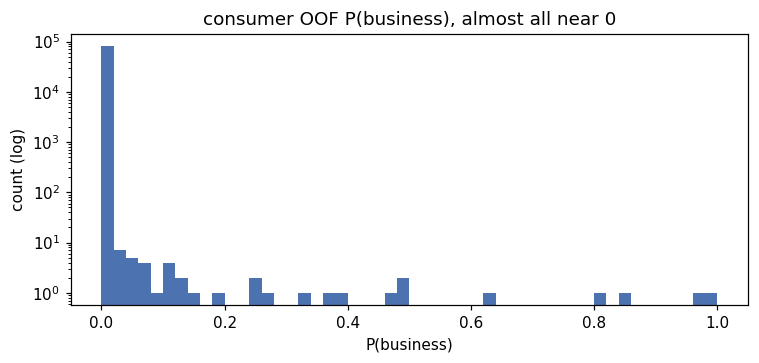

In [16]:
con = feat[feat.label == 0].copy()
biz = feat[feat.label == 1].copy()
print(f"consumers={len(con):,}  businesses={len(biz):,}")
print("consumers above each cutoff:")
for t in [0.1, 0.2, 0.3, 0.5, 0.8, 0.9]:
    n = int((con.oof_p >= t).sum())
    print(f"  P>={t:.2f}: {n:,} ({n/len(con)*100:.3f}%)")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(con.oof_p, bins=np.linspace(0, 1, 51), color="#4C72B0")
ax.set_yscale("log")
ax.set_title("consumer OOF P(business), almost all near 0")
ax.set_xlabel("P(business)"); ax.set_ylabel("count (log)")
plt.tight_layout(); plt.show()

In [17]:
leads = con[con.oof_p >= LEAD_THR].sort_values("oof_p", ascending=False)
if len(leads) < 10:
    # fallback so a sparse synthetic pool still gives the analyst something to look at
    leads = con.sort_values("oof_p", ascending=False).head(25)

profile_cols = ["oof_p","amt_sum","amt_median","online_share","recurring_share",
                "b2b_mcc_share","b2b_amt_share","b2b_unique_merchants",
                "recurring_capable_share","merchant_top_ratio","bizhours_share"]
profile = pd.DataFrame({
    "typical_consumer":    con[profile_cols].median(),
    "hidden_entrepreneur": leads[profile_cols].median(),
    "typical_business":    biz[profile_cols].median(),
})
print(f"{len(leads)} leads (P>={LEAD_THR}). median profile vs baselines:")
display(profile.round(3))


def reason_codes(idx, k=5):
    rc = pd.Series(shap_positive(expl, leads.loc[[idx], FEATURES])[0],
                   index=FEATURES).sort_values(key=np.abs, ascending=False).head(k)
    return ", ".join(f"{f}({'+' if v >= 0 else ''}{v:.2f})" for f, v in rc.items())


leads["reason_codes"] = [reason_codes(i) for i in leads.index]
leads[[ID_COL] + profile_cols + ["reason_codes"]].to_csv(LEADS_FILE, index=False)
print(f"\nsaved {LEADS_FILE} ({len(leads)} rows)")
display(leads[[ID_COL, "oof_p", "amt_sum", "b2b_amt_share", "reason_codes"]].head(10))

11 leads (P>=0.3). median profile vs baselines:


,typical_consumer,hidden_entrepreneur,typical_business
oof_p,0.000,4.990000e-01,1.000000e+00
amt_sum,2976294.000,1.607314e+07,1.771489e+07
amt_median,9673.500,1.700600e+05,8.455850e+04
online_share,0.447,8.540000e-01,8.520000e-01
recurring_share,0.000,2.310000e-01,1.340000e-01
b2b_mcc_share,0.016,6.570000e-01,6.180000e-01
b2b_amt_share,0.015,8.890000e-01,8.090000e-01
b2b_unique_merchants,1.000,3.000000e+00,7.000000e+00
recurring_capable_share,0.032,4.230000e-01,2.940000e-01
merchant_top_ratio,0.111,4.160000e-01,3.710000e-01



saved hidden_entrepreneurs.csv (11 rows)


,card_number,oof_p,amt_sum,b2b_amt_share,reason_codes
33712,5201491354169846,0.992272,13635876.0,0.380593,"evening_share(+4.14), tokenized_share(-3.99), ..."
97236,5531513098848970,0.967799,21549560.0,0.988027,"evening_share(+3.52), recurring_capable_share(..."
41262,5228591076618522,0.858703,28168049.0,0.996915,"evening_share(+4.18), recurring_capable_share(..."
48636,5228597629027905,0.802855,16073145.0,0.907113,"tokenized_share(-4.43), evening_share(+4.09), ..."
38766,5211556274611016,0.621410,44568391.0,0.911789,"tokenized_share(-6.33), evening_share(+4.31), ..."
16663,5176476691114937,0.499405,9039253.0,0.664393,"tokenized_share(-6.01), evening_share(+3.46), ..."
80230,5486025422486893,0.496688,7412060.0,0.131825,"evening_share(+3.88), online_share(+2.29), b2b..."
24375,5176515892188610,0.469884,51837033.0,0.955637,"tokenized_share(-4.37), evening_share(+4.23), ..."
61581,5368296289935651,0.395695,13557014.0,0.786214,"tokenized_share(-6.24), evening_share(+3.68), ..."
87528,5486736922135513,0.375246,5764545.0,0.819011,"evening_share(+5.06), tokenized_share(-2.83), ..."


## 15. Business mapping

The model picks up a fairly clean SME signature: high online share, more activity
in business hours than evenings, larger and more concentrated B2B spend, and a
recurring-payment cadence. Each of those maps to a bank product:

- **POS acquiring** for cards with high online share + merchant concentration.
- **Working-capital loans** for cards with large recurring B2B outflows.
- **Payroll / salary projects** for cards with high recurring share to many
  counterparties.
- **Tariff migration** to an SME plan once `amt_sum` and `amt_median` cross the
  consumer band.
- **Cash management and bookkeeping** for cards with a broad B2B supplier base.
- **FX / cross-border** offer for cards with `foreign_share` above ~0.2.

Operationally: outreach-threshold list goes to an RM with the reason codes;
F1-max threshold is the strict gate for automated migration.

## 16. Methodology notes

1. **Unit & label.** 105 000 cards, 23.8 % business. One row per `card_number`.
2. **Features (35).** Card-level aggregates only: amount shape, merchant
   diversity and concentration, curated B2B exposure, temporal pattern,
   recurring behavior, monthly stability, inter-arrival burstiness, recency.
3. **Leakage handling.** `card_tier` and `bank_name` dropped; raw `mcc` and
   `merchant_id` never one-hot encoded; B2B basket curated from MCC semantics
   and checked to contain zero business-exclusive codes.
4. **Validation.** Stratified 80/20 on cards; preprocessing inside a Pipeline so
   it is fit on train only; thresholds tuned on train OOF; leads scored OOF.
5. **Models.** LogReg, LightGBM, RandomForest all reach ROC-AUC ~1.0 on this
   synthetic data. We keep LightGBM as the main model for SHAP.
6. **Metrics.** ROC-AUC, PR-AUC, plus confusion matrices and the classification
   report at the two tuned thresholds.
7. **Caveat.** The near-perfect score reflects clean synthetic separation; the
   ranking and explanations transfer, the absolute numbers will not.

## 17. Scoring a new test set

If a held-out test parquet arrives with the same schema, the recipe is short:

```python
test_tx = pd.read_parquet("test_cards.parquet")
test_tx["label"] = 0
test_feat = build_card_features(test_tx, merchants)
final = make_lgbm().fit(feat[FEATURES], feat[LABEL_COL])
test_feat["score"] = final.predict_proba(test_feat[FEATURES])[:, 1]
test_feat[[ID_COL, "score"]].to_csv("test_submission.csv", index=False)
```

The cell below does the same refit + score on the labeled data and overwrites
`submission.csv` with the full-fit model's predictions, which is what we ship.

In [18]:
final = make_lgbm().fit(feat[FEATURES], feat[LABEL_COL])
feat["score"] = final.predict_proba(feat[FEATURES])[:, 1]
print("full-refit ranking:",
      {k: round(v, 4) for k, v in ranking_metrics(feat[LABEL_COL], feat.score).items()})
feat[[ID_COL, "score"]].to_csv(SUBMISSION, index=False)
print(f"overwrote {SUBMISSION} with full-refit scores")

full-refit ranking: {'ROC_AUC': 1.0, 'PR_AUC': 1.0}


overwrote submission.csv with full-refit scores
